# Quick UrQMD ROOT plots

Run this notebook in the `urqmd` environment. It auto-finds a ROOT file and makes quick sanity plots.

In [ ]:
print("hello world")

In [1]:
import glob
import math
from pathlib import Path
import ROOT
import matplotlib.pyplot as plt

ROOT.gROOT.SetBatch(True)

In [2]:
base = Path("../../UrQMD_C_Code").resolve()

root_files = sorted(base.rglob("*.root"))

print(f"Found {len(root_files)} ROOT file(s):")
for path in root_files:
    print(" ", path)

if not root_files:
    raise FileNotFoundError(f"No .root files found below {base}")

root_path = root_files[0]
print("\nUsing:", root_path)

Found 1 ROOT file(s):
  /workspace/research/UrQMD_C_Code/r_urqmd/Event_10.root

Using: /workspace/research/UrQMD_C_Code/r_urqmd/Event_10.root


In [7]:
f = ROOT.TFile.Open(str(root_path))

if not f or f.IsZombie():
    raise OSError(f"Could not open ROOT file: {root_path}")

t = f.Get("urqmd")

if not t:
    print("Objects in this ROOT file:")
    f.ls()
    raise KeyError("Could not find a tree named 'urqmd'")

print("Tree:", t.GetName())
print("Entries:", t.GetEntries())

t.Print()

Tree: urqmd1
Entries: 10
******************************************************************************
*Tree    :urqmd1    : urqmd                                                  *
*Entries :       10 : Total =           79048 bytes  File  Size =          0 *
*        :          : Tree compression factor =   1.00                       *
******************************************************************************
*Br    0 :mul       : mul/I                                                  *
*Entries :       10 : Total  Size=        677 bytes  One basket in memory    *
*Baskets :        0 : Basket Size=      32000 bytes  Compression=   1.00     *
*............................................................................*
*Br    1 :b         : b/F                                                    *
*Entries :       10 : Total  Size=        665 bytes  One basket in memory    *
*Baskets :        0 : Basket Size=      32000 bytes  Compression=   1.00     *
*..........................

In [10]:
for branch in t.GetListOfBranches():
    print(branch.GetName())

mul
b
Npart
pid
px
py
pz


In [11]:
npart = []
bvals = []
mul = []

all_pid = []
all_pt = []
all_pz = []

for ev in t:
    npart.append(int(ev.Npart))
    bvals.append(float(ev.b))

    event_mul = int(ev.mul)
    mul.append(event_mul)

    for i in range(event_mul):
        px = float(ev.px[i])
        py = float(ev.py[i])
        pz = float(ev.pz[i])

        all_pid.append(int(ev.pid[i]))
        all_pt.append(math.sqrt(px**2 + py**2))
        all_pz.append(pz)

print(f"Loaded {len(npart)} events and {len(all_pid)} particles")

Loaded 10 events and 4624 particles


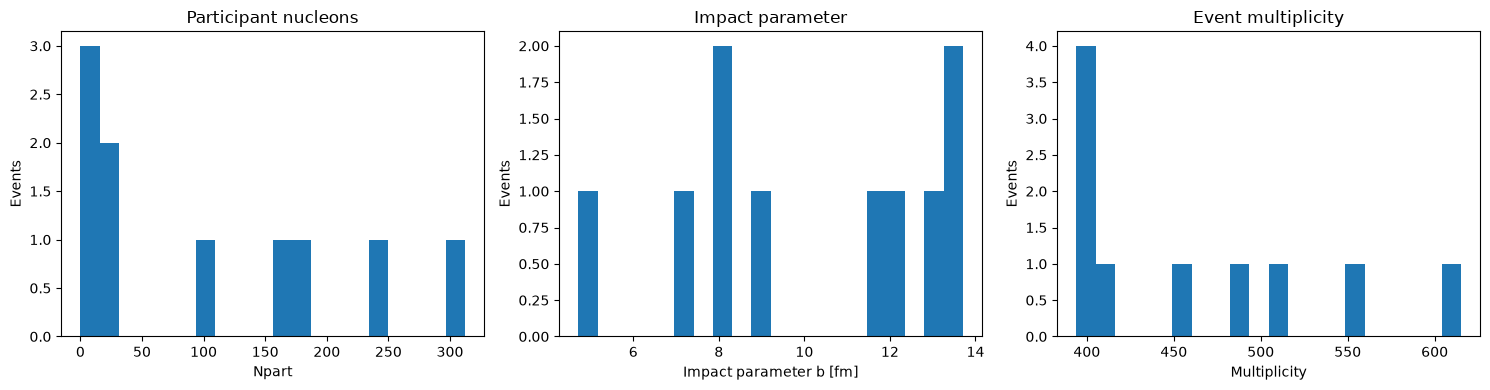

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(npart, bins=20)
ax[0].set_xlabel("Npart")
ax[0].set_ylabel("Events")
ax[0].set_title("Participant nucleons")

ax[1].hist(bvals, bins=20)
ax[1].set_xlabel("Impact parameter b [fm]")
ax[1].set_ylabel("Events")
ax[1].set_title("Impact parameter")

ax[2].hist(mul, bins=20)
ax[2].set_xlabel("Multiplicity")
ax[2].set_ylabel("Events")
ax[2].set_title("Event multiplicity")

fig.tight_layout()
plt.show()

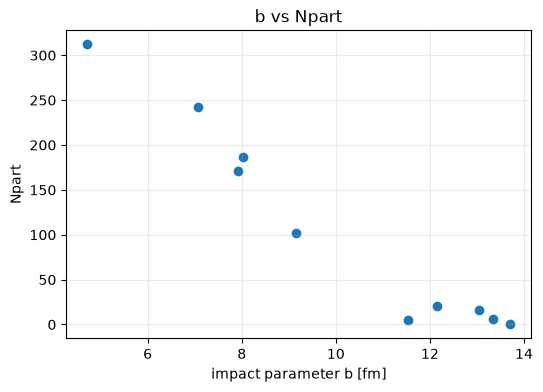

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(bvals, npart)
plt.xlabel('impact parameter b [fm]')
plt.ylabel('Npart')
plt.title('b vs Npart')
plt.grid(alpha=0.25)
plt.show()


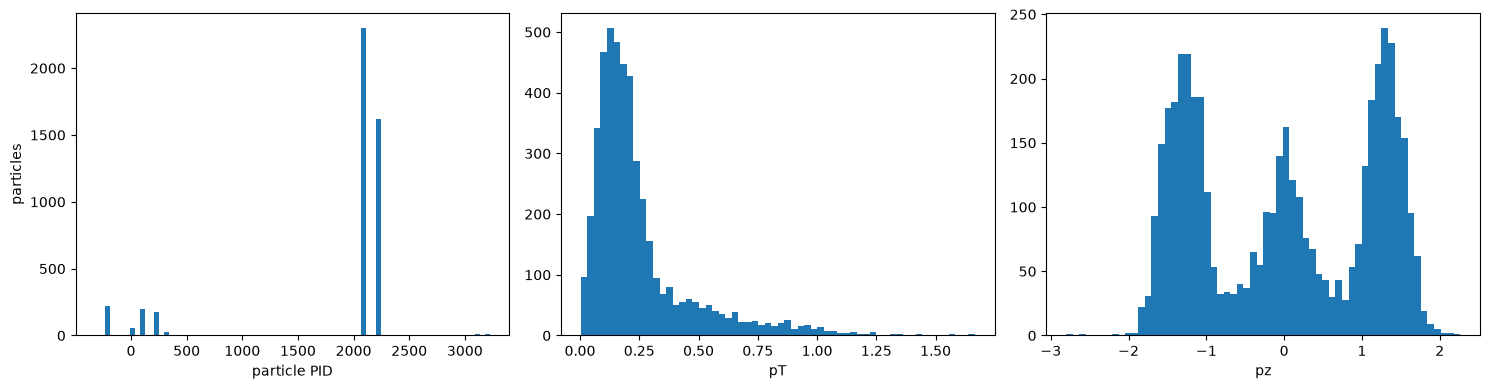

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(all_pid, bins=80); ax[0].set_xlabel('particle PID'); ax[0].set_ylabel('particles')
ax[1].hist(all_pt, bins=60); ax[1].set_xlabel('pT')
ax[2].hist(all_pz, bins=60); ax[2].set_xlabel('pz')
fig.tight_layout(); plt.show()
